In [ ]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("processed_dataset.csv")

Epoch [10/200] | Loss: 2.3136
Epoch [20/200] | Loss: 1.3057
Epoch [30/200] | Loss: 0.9705
Epoch [40/200] | Loss: 0.8214
Epoch [50/200] | Loss: 0.8283
Epoch [60/200] | Loss: 0.6743
Epoch [70/200] | Loss: 1.0190
Epoch [80/200] | Loss: 0.9240
Epoch [90/200] | Loss: 0.6243
Epoch [100/200] | Loss: 0.7718
Epoch [110/200] | Loss: 0.8959
Epoch [120/200] | Loss: 0.7952
Epoch [130/200] | Loss: 0.7407
Epoch [140/200] | Loss: 0.6645
Epoch [150/200] | Loss: 0.7781
Epoch [160/200] | Loss: 0.4826
Epoch [170/200] | Loss: 0.6206
Epoch [180/200] | Loss: 0.6034
Epoch [190/200] | Loss: 0.5277
Epoch [200/200] | Loss: 0.5583

========== PYTORCH NN RESULTS ==========
MAE  : 0.9298
RMSE : 1.1092
R2   : 0.3601

========== RANDOM FOREST RESULTS ==========
MAE  : 0.6931
RMSE : 0.8385
R2   : 0.6344

========== EXTRA TREES RESULTS ==========
MAE  : 0.5810
RMSE : 0.7764
R2   : 0.6865

========== GRADIENT BOOSTING RESULTS ==========
MAE  : 0.7233
RMSE : 0.9111
R2   : 0.5682

========== FINAL MODEL COMPARISON =======

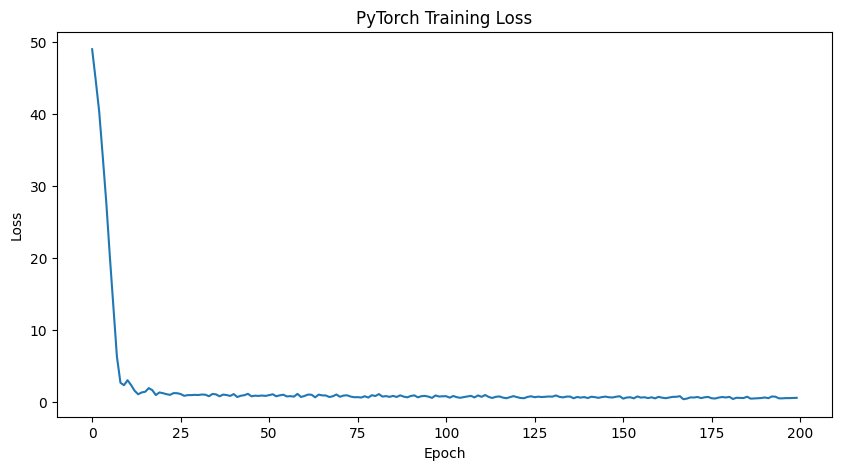


========== SAMPLE PREDICTIONS ==========
   Actual_SCORE  Predicted_SCORE
0      4.270024         5.693695
1      9.100000         7.445859
2      5.396000         5.179155
3      8.200000         5.823755
4      7.860000         6.640640
5      7.662000         9.188886
6      8.370000         6.717982
7      5.440000         5.132830
8      4.500000         4.811183
9      5.630000         4.648365

PyTorch model saved.


In [ ]:
# ============================================================
# ADVANCED PYTORCH + ENSEMBLE MODELS
# ============================================================


# ============================================================
# FEATURES & TARGET
# ============================================================

features = [
    "DRIVER_POINTS_BEFORE_RACE",
    "LAPS",
    "MILLISECONDS",
    "WEATHER_rain",
    "WEATHER_WET",
    "WEATHER_cloudy",
    "OVERTAKEN_POSITIONS_TOTAL",
    "DNF_COUNT",
    "LAPMEAN",
    "FASTESTLAP",
    "PS_COUNT",
    "SC_COUNT",
    "ROLLING_POINTS",
    "ROLLING_LAP",
    "LAP_CONSISTENCY",
    "RACE_INTERRUPTIONS",
    "OVERTAKE_RATIO",
    "DRIVER_ENCODED",
    "RACE_ENCODED"
]

target = "SCORE"

# ============================================================
# CLEAN DATA
# ============================================================

model_df = df[features + [target]].copy()

model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna()

X = model_df[features]
y = model_df[target].values

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# PYTORCH TENSORS
# ============================================================

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# ============================================================
# DATALOADER
# ============================================================

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# ============================================================
# ADVANCED PYTORCH MODEL
# ============================================================

class F1NeuralNetwork(nn.Module):

    def __init__(self, input_size):
        super(F1NeuralNetwork, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

# ============================================================
# INITIALIZE MODEL
# ============================================================

input_size = X_train.shape[1]

model = F1NeuralNetwork(input_size)

# ============================================================
# LOSS + OPTIMIZER
# ============================================================

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

# ============================================================
# TRAINING
# ============================================================

epochs = 200

losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        predictions = model(batch_X)

        loss = criterion(predictions, batch_y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f}")

# ============================================================
# PREDICTIONS
# ============================================================

model.eval()

with torch.no_grad():

    y_pred_tensor = model(X_test_tensor)

y_pred_nn = y_pred_tensor.numpy().flatten()

# ============================================================
# NN METRICS
# ============================================================

nn_mae = mean_absolute_error(y_test, y_pred_nn)
nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
nn_r2 = r2_score(y_test, y_pred_nn)

print("\n========== PYTORCH NN RESULTS ==========")
print(f"MAE  : {nn_mae:.4f}")
print(f"RMSE : {nn_rmse:.4f}")
print(f"R2   : {nn_r2:.4f}")

# ============================================================
# RANDOM FOREST
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\n========== RANDOM FOREST RESULTS ==========")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R2   : {rf_r2:.4f}")

# ============================================================
# EXTRA TREES
# ============================================================

et_model = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

et_model.fit(X_train, y_train)

et_pred = et_model.predict(X_test)

et_mae = mean_absolute_error(y_test, et_pred)
et_rmse = np.sqrt(mean_squared_error(y_test, et_pred))
et_r2 = r2_score(y_test, et_pred)

print("\n========== EXTRA TREES RESULTS ==========")
print(f"MAE  : {et_mae:.4f}")
print(f"RMSE : {et_rmse:.4f}")
print(f"R2   : {et_r2:.4f}")

# ============================================================
# GRADIENT BOOSTING
# ============================================================

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("\n========== GRADIENT BOOSTING RESULTS ==========")
print(f"MAE  : {gb_mae:.4f}")
print(f"RMSE : {gb_rmse:.4f}")
print(f"R2   : {gb_r2:.4f}")

# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "PyTorch Neural Network",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting"
    ],
    "MAE": [
        nn_mae,
        rf_mae,
        et_mae,
        gb_mae
    ],
    "RMSE": [
        nn_rmse,
        rf_rmse,
        et_rmse,
        gb_rmse
    ],
    "R2": [
        nn_r2,
        rf_r2,
        et_r2,
        gb_r2
    ]
})

comparison = comparison.sort_values(
    by="R2",
    ascending=False
)

print("\n========== FINAL MODEL COMPARISON ==========")
print(comparison)

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": et_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========")
print(importance_df)

# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(losses)

plt.title("PyTorch Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

results = pd.DataFrame({
    "Actual_SCORE": y_test,
    "Predicted_SCORE": y_pred_nn
})

print("\n========== SAMPLE PREDICTIONS ==========")
print(results.head(10))

# ============================================================
# SAVE MODELS
# ============================================================

torch.save(model.state_dict(), "f1_pytorch_model.pth")

print("\nPyTorch model saved.")
